In [86]:
import numpy as np

# Parameters
n = 328  # Number of lines to skip
N = 200  # Number of lines to read

# File name
file_name = "logs/log.amine_polymers"

# Read the file
with open(file_name, 'r') as file:
    # Skip the first n lines
    for _ in range(n):
        next(file)
    print(f"Skipped {n} lines.")
    # print(f"First line after skipping: {file.readline().strip()}")
    # file.seek(0)  # Reset file pointer to the beginning
    
    # Read the next N lines and convert to numpy array column-wise
    data = np.array([list(map(float, next(file).strip().split())) for _ in range(N)]).T

# print(data[:5])
print(np.mean(data, axis=1))  # mean of each column
print(np.std(data, axis=1))   # std deviation of each column

Skipped 328 lines.
[ 2.00500000e+04  9.99448577e-01 -1.38480559e-01  5.58240295e-01
  1.91438966e+00  2.38500942e-04]
[5.77343052e+03 4.55283440e-02 7.51098870e-02 6.04734940e-02
 8.38226557e-02 1.01761652e-03]


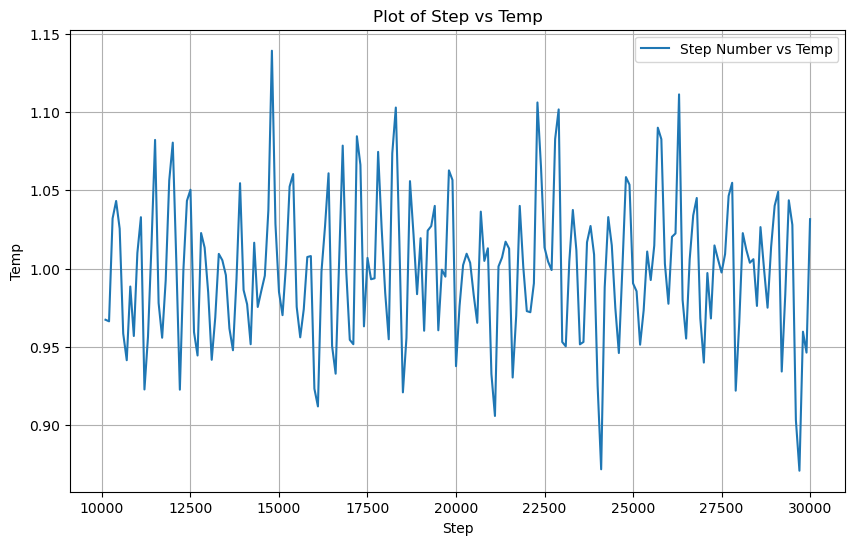

In [77]:
import matplotlib.pyplot as plt

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(data[0], data[1], label='Step Number vs Temp')
plt.xlabel('Step')
plt.ylabel('Temp')
plt.title('Plot of Step vs Temp')
plt.legend()
plt.grid()
plt.show()

In [61]:
def calc_diff_coeff(logfile, skip_lines, bin_size=1000, slope_method=True):
    """
    Calculate the diffusion coefficient from a LAMMPS MSD log file.

    Parameters:
        logfile (str): Path to the LAMMPS log file. Format is two columns: timesteps and MSD.
        skip_lines (int): Number of header lines to skip.
        bin_size (int): Number of values per group to fit linearly to.
    """
    # Read the file
    data = np.loadtxt(logfile, skiprows=skip_lines)
    # Calculate the diffusion coefficient
    if slope_method:
        # Fit a line to the MSD data in bins of size bin_size
        num_bins = data.shape[0] // bin_size
        slopes = []
        for i in range(num_bins):
            start = i * bin_size
            end = start + bin_size
            if end > data.shape[0]:
                break
            # Fit a line to the data in this bin
            coeffs = np.polyfit(data[start:end, 0], data[start:end, 1], 1)
            slopes.append(coeffs[0])
        # Average the slopes and calculate the diffusion coefficient
        # avg_slope = np.mean(slopes)
        diffusion_coefficient = np.array(slopes) / 6
    else:
        diffusion_coefficient = data[:, 1] / (6 * data[:, 0])
    return diffusion_coefficient

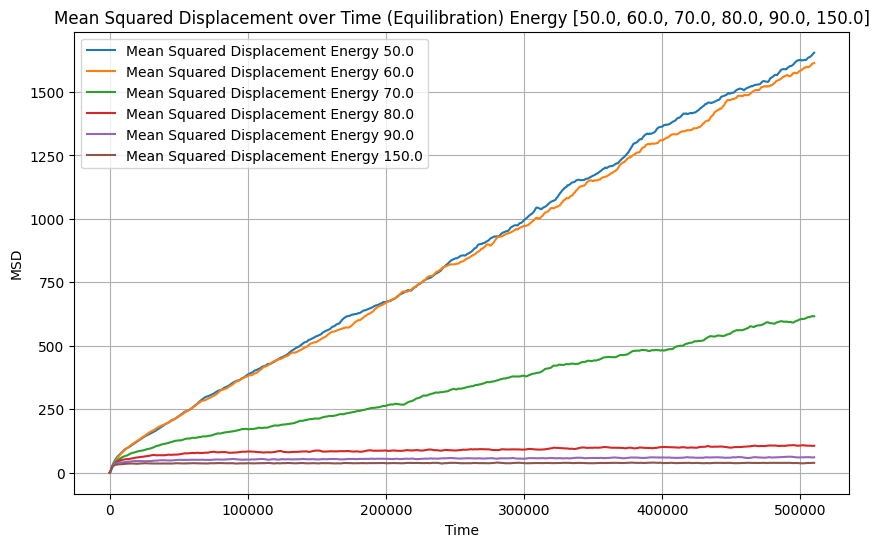

In [16]:
import numpy as np
import matplotlib.pyplot as plt

energies = [0.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0]
energies = [50.0, 60.0, 70.0, 80.0, 90.0, 150.0]
# energies = [0.0, 10., 100.0]
def plot_energy_msd(energies):
    plt.figure(figsize=(10, 6))
    for energy in energies:
        file = f'logs/energy_{int(energy)}.0.dat'
        data = np.loadtxt(file, skiprows=2)  # skip the header row
        
        plt.plot(data[:, 0], data[:, 1], label=f'Mean Squared Displacement Energy {energy}')
    plt.xlabel('Time')
    plt.ylabel('MSD')
    plt.title(f'Mean Squared Displacement over Time (Equilibration) Energy {energies}')
    plt.legend()
    plt.grid()
    plt.show()

plot_energy_msd(energies)


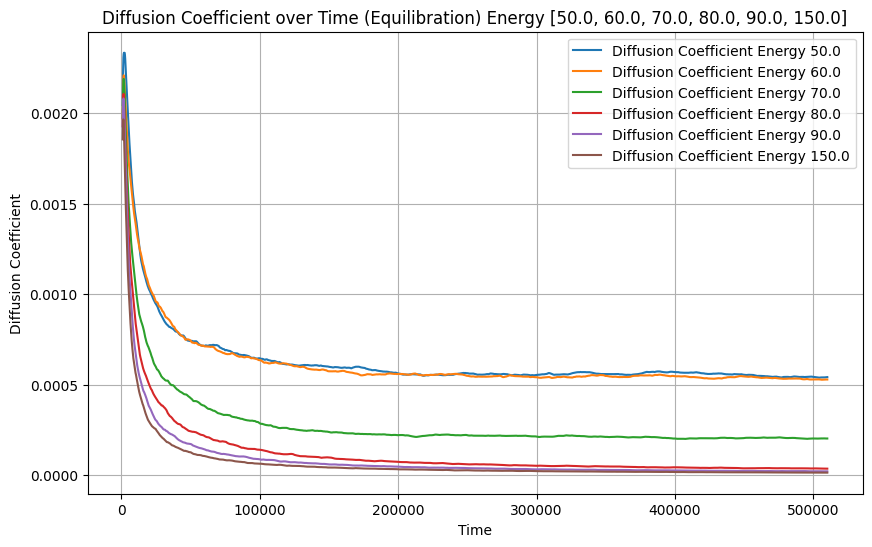

In [17]:

def plot_energy_diffusion(energies):
    
    # Plot the diffusion coefficient as a function of time
    plt.figure(figsize=(10, 6))
    for energy in energies:
        file = f'logs/energy_{int(energy)}.0.dat'
        data = np.loadtxt(file, skiprows=2)  # skip the header row
        # diffusion_coefficient = calc_diff_coeff(file, skip_lines=2, bin_size=200, slope_method=True)
        diffusion_coefficient = data[100:, 1] / (6 * data[100:, 0])
        plt.plot(data[100:, 0], diffusion_coefficient, label=f'Diffusion Coefficient Energy {energy}')
    plt.xlabel('Time')
    plt.ylabel('Diffusion Coefficient')
    plt.title(f'Diffusion Coefficient over Time (Equilibration) Energy {energies}')
    plt.legend()
    plt.grid()
    plt.show()

plot_energy_diffusion(energies)


/tmp/ipykernel_451771/2959240378.py:8: RuntimeWarning: invalid value encountered in divide
  diffusion_coefficient = data[:, 1] / (6 * data[:, 0])


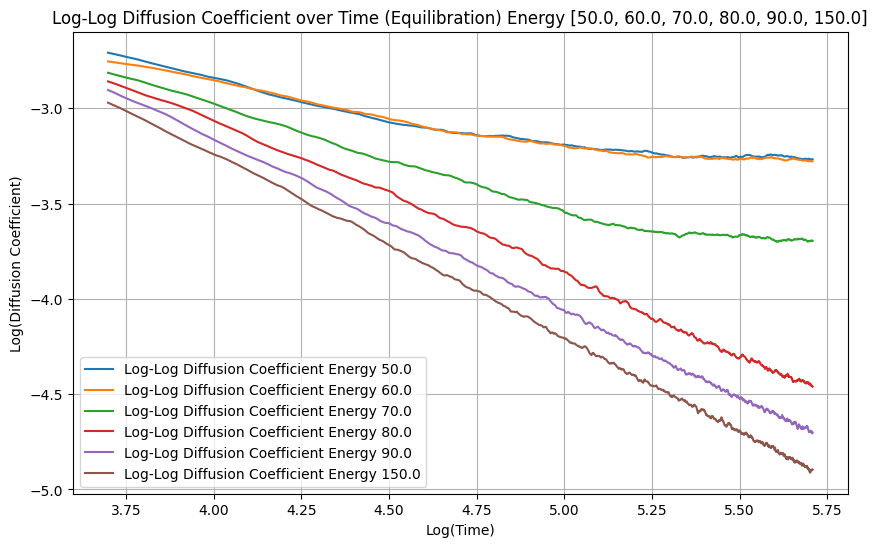

In [18]:
# log-log plot
def loglogplot(energies):
    
    plt.figure(figsize=(10, 6))
    for energy in energies:
        file = f'logs/energy_{int(energy)}.0.dat'
        data = np.loadtxt(file, skiprows=2)  # skip the header row
        diffusion_coefficient = data[:, 1] / (6 * data[:, 0])
        log_diff = np.log10(diffusion_coefficient)
        log_time = np.log10(data[:, 0] + 1e-10)
        plt.plot(log_time[500:], log_diff[500:], label=f'Log-Log Diffusion Coefficient Energy {energy}')
    plt.xlabel('Log(Time)')
    plt.ylabel('Log(Diffusion Coefficient)')
    plt.title(f'Log-Log Diffusion Coefficient over Time (Equilibration) Energy {energies}')
    plt.legend()
    plt.grid()
    plt.show()

loglogplot(energies)


In [73]:
# read data/pair_hbond.dat
data = np.loadtxt('data/pair_hbond.dat', skiprows=6)
plt.figure(figsize=(10, 6))
plt.plot(data[:, 1], data[:, 2], label='Hydrogen Bond Potential')
plt.xlabel('Distance (r)')
plt.ylabel('Potential Energy')
plt.ylim(-1, 5)
plt.xlim(0, 3)
plt.title('Hydrogen Bond Potential vs Distance')
plt.legend()
plt.grid()
plt.show()


ValueError: the number of columns changed from 4 to 1 at row 501; use `usecols` to select a subset and avoid this error